# Machine Learning untuk Klasifikasi Real vs Fake

Notebook ini mendemonstrasikan fase Machine Learning pada final project Computer Vision. Tujuan utamanya adalah membangun pipeline klasifikasi sederhana untuk membedakan citra `real` dan `fake` berdasarkan fitur statistik yang diperoleh dari proses ekstraksi fitur lokal dan feature matching.

Dalam konteks ini, setiap citra direpresentasikan sebagai feature vector. Feature vector adalah kumpulan nilai numerik yang merangkum karakteristik citra, misalnya jumlah keypoint, rata-rata descriptor, variasi descriptor, dan jumlah good matches. Nilai-nilai ini kemudian digunakan oleh model classical machine learning untuk belajar pola antara citra real dan fake.

Project ini menggunakan fitur statistik dari SIFT, ORB, AKAZE, serta statistik feature matching. Model yang digunakan adalah Random Forest dan Support Vector Machine (SVM). Keduanya termasuk metode classical machine learning, sehingga pipeline ini tidak menggunakan deep learning framework.

## Import Library dan ML Pipeline

Bagian ini mengimpor library dasar untuk manipulasi data, visualisasi, dan pembagian data train-test. Notebook ini juga mengimpor fungsi reusable dari `src/ml_pipeline.py` agar logic utama pipeline tidak diduplikasi di notebook.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split

try:
    from IPython.display import display
except ImportError:
    display = print

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.ml_pipeline import (
    load_matching_summary,
    load_feature_statistics,
    build_feature_dataset,
    infer_labels,
    preprocess_features,
    train_random_forest,
    train_svm,
    evaluate_model,
    save_results,
)

MATCHING_SUMMARY_PATH = PROJECT_ROOT / "outputs" / "matching" / "all_matching_summary.csv"
FEATURE_STATISTICS_PATH = PROJECT_ROOT / "outputs" / "feature_statistics.csv"
RESULTS_PATH = PROJECT_ROOT / "outputs" / "results" / "ml_evaluation_results.csv"
FIGURES_DIR = PROJECT_ROOT / "outputs" / "figures"

plt.rcParams["figure.figsize"] = (9, 5)

## Load Feature Dataset

Dataset fitur dapat berasal dari beberapa sumber CSV. File `all_matching_summary.csv` berisi statistik robustness matching, seperti jumlah keypoint original, jumlah keypoint augmentasi, dan jumlah good matches. File `feature_statistics.csv`, jika tersedia, berisi statistik descriptor seperti jumlah keypoint, rata-rata descriptor, dan variansi descriptor.

Jika salah satu CSV belum tersedia, pipeline akan memberi warning yang jelas dan tetap melanjutkan proses dengan data yang ada.

In [2]:
matching_df = load_matching_summary()
feature_stats_df = load_feature_statistics()

print("Matching summary")
print(f"Rows: {matching_df.shape[0]}, Columns: {matching_df.shape[1]}")
display(matching_df.head())

print("\nFeature statistics")
print(f"Rows: {feature_stats_df.shape[0]}, Columns: {feature_stats_df.shape[1]}")
display(feature_stats_df.head())

Loaded matching summary: C:\Users\Kei\Documents\computer-vision\Comp_pision\outputs\matching\all_matching_summary.csv (18 rows)
Loaded feature statistics: C:\Users\Kei\Documents\computer-vision\Comp_pision\outputs\feature_statistics.csv (480 rows)
Matching summary
Rows: 18, Columns: 8


,label,method,augmentation,image_a,image_b,keypoints_original,keypoints_augmented,good_matches
0,real,SIFT,gaussian_blur,C:\Users\Kei\Documents\computer-vision\Comp_pi...,C:\Users\Kei\Documents\computer-vision\Comp_pi...,44,32,26
1,real,SIFT,gaussian_noise,C:\Users\Kei\Documents\computer-vision\Comp_pi...,C:\Users\Kei\Documents\computer-vision\Comp_pi...,44,57,20
2,real,SIFT,jpeg_compression,C:\Users\Kei\Documents\computer-vision\Comp_pi...,C:\Users\Kei\Documents\computer-vision\Comp_pi...,44,47,31
3,real,ORB,gaussian_blur,C:\Users\Kei\Documents\computer-vision\Comp_pi...,C:\Users\Kei\Documents\computer-vision\Comp_pi...,11,3,4
4,real,ORB,gaussian_noise,C:\Users\Kei\Documents\computer-vision\Comp_pi...,C:\Users\Kei\Documents\computer-vision\Comp_pi...,11,150,4



Feature statistics
Rows: 480, Columns: 8


,image_path,label,method,augmentation,num_keypoints,descriptor_shape,descriptor_mean,descriptor_variance
0,dataset/original/train/real/id0_0000_f0000_ori...,real,SIFT,original,44,"(44, 128)",24.9556,1426.3595
1,dataset/original/train/real/id0_0000_f0000_ori...,real,ORB,original,11,"(11, 32)",137.5114,5101.8919
2,dataset/original/train/real/id0_0000_f0000_ori...,real,AKAZE,original,5,"(5, 61)",118.3902,8762.5265
3,dataset/original/train/real/id0_0000_f0052_ori...,real,SIFT,original,42,"(42, 128)",25.0826,1418.8365
4,dataset/original/train/real/id0_0000_f0052_ori...,real,ORB,original,9,"(9, 32)",151.2882,5598.1704


## Membangun Dataset Fitur

Pada tahap ini, statistik matching dan statistik descriptor digabungkan menjadi satu dataframe. Label `real` dan `fake` dicoba diambil dari kolom `image_path`. Jika path mengandung folder `/real/`, label dianggap `real`. Jika path mengandung folder `/fake/`, label dianggap `fake`.

Label sangat penting karena model supervised learning membutuhkan pasangan input feature dan target label.

In [3]:
feature_dataset = build_feature_dataset(matching_df, feature_stats_df)
labeled_dataset = infer_labels(feature_dataset)

print(f"Combined rows: {labeled_dataset.shape[0]}")
print(f"Combined columns: {labeled_dataset.shape[1]}")
display(labeled_dataset.head())

print("\nDistribusi label:")
display(labeled_dataset["label"].value_counts(dropna=False))

Built combined feature dataset: 498 rows
Combined rows: 498
Combined columns: 10


,method,augmentation,keypoints_original,keypoints_augmented,good_matches,num_keypoints,descriptor_mean,descriptor_variance,image_path,label
0,SIFT,gaussian_blur,44.0,32,26.0,32,NaN,NaN,C:\Users\Kei\Documents\computer-vision\Comp_pi...,real
1,SIFT,gaussian_noise,44.0,57,20.0,57,NaN,NaN,C:\Users\Kei\Documents\computer-vision\Comp_pi...,real
2,SIFT,jpeg_compression,44.0,47,31.0,47,NaN,NaN,C:\Users\Kei\Documents\computer-vision\Comp_pi...,real
3,ORB,gaussian_blur,11.0,3,4.0,3,NaN,NaN,C:\Users\Kei\Documents\computer-vision\Comp_pi...,real
4,ORB,gaussian_noise,11.0,150,4.0,150,NaN,NaN,C:\Users\Kei\Documents\computer-vision\Comp_pi...,real



Distribusi label:


label
real    249
fake    249
Name: count, dtype: int64

## Preprocessing Feature

Preprocessing mengubah dataframe mentah menjadi matriks fitur `X` dan target `y`. Kolom kategorikal seperti `method` dan `augmentation` diubah menggunakan one-hot encoding. Nilai label dikonversi menjadi angka: `real = 0` dan `fake = 1`. Missing values pada fitur numerik diisi dengan 0 agar model dapat menerima input dalam bentuk numerik lengkap.

In [4]:
X, y = preprocess_features(labeled_dataset)

print(f"Shape X: {X.shape}")
print(f"Shape y: {y.shape}")
print("\nPreview encoded features:")
display(X.head())

Prepared feature matrix: 498 rows x 13 columns
Shape X: (498, 13)
Shape y: (498,)

Preview encoded features:


,keypoints_original,keypoints_augmented,good_matches,num_keypoints,descriptor_mean,descriptor_variance,method_AKAZE,method_ORB,method_SIFT,augmentation_gaussian_blur,augmentation_gaussian_noise,augmentation_jpeg_compression,augmentation_original
0,44.0,32,26.0,32,0.0,0.0,False,False,True,True,False,False,False
1,44.0,57,20.0,57,0.0,0.0,False,False,True,False,True,False,False
2,44.0,47,31.0,47,0.0,0.0,False,False,True,False,False,True,False
3,11.0,3,4.0,3,0.0,0.0,False,True,False,True,False,False,False
4,11.0,150,4.0,150,0.0,0.0,False,True,False,False,True,False,False


## Pemeriksaan Dataset

Sebelum training, dataset harus diperiksa terlebih dahulu. Evaluasi klasifikasi hanya valid jika terdapat dua kelas, yaitu `real` dan `fake`. Jika dataset hanya memiliki satu kelas, model tidak dapat belajar boundary pemisah yang bermakna.

Bagian ini sengaja dibuat eksplisit agar pada demo presentasi terlihat bahwa validitas evaluasi bergantung pada ketersediaan data dari kedua kelas.

In [5]:
label_names = y.map({0: "real", 1: "fake"}) if not y.empty else pd.Series(dtype="object")
class_counts = label_names.value_counts()

print("Jumlah class:")
display(class_counts)

can_train = (not X.empty) and (y.nunique() == 2) and (y.value_counts().min() >= 2)

if not can_train:
    print("\nWARNING:")
    print("Dataset belum memenuhi syarat untuk training dan evaluasi klasifikasi yang valid.")
    print("Machine Learning membutuhkan sample dari dua kelas: real dan fake.")
    print("Jika hanya satu kelas tersedia, model tidak dapat mempelajari pemisahan real vs fake.")
else:
    print("Dataset memiliki dua kelas dan siap untuk train-test split.")

Jumlah class:


label
real    249
fake    249
Name: count, dtype: int64

Dataset memiliki dua kelas dan siap untuk train-test split.


## Train-Test Split

Dataset dibagi menjadi data training dan data evaluation. Data training digunakan untuk melatih model, sedangkan data test digunakan untuk mengukur kemampuan model pada data yang tidak dilihat saat training. Jika kedua kelas tersedia, split dilakukan dengan stratify agar proporsi kelas tetap seimbang.

In [6]:
if can_train:
    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.3,
        random_state=42,
        stratify=y,
    )
    print(f"Jumlah data train: {len(X_train)}")
    print(f"Jumlah data test: {len(X_test)}")
else:
    X_train = X_test = y_train = y_test = None
    print("Train-test split dilewati karena dataset belum memiliki dua kelas yang cukup.")

Jumlah data train: 348
Jumlah data test: 150


## Training Random Forest

Random Forest menggunakan banyak decision tree dan menggabungkan hasilnya untuk melakukan klasifikasi. Model ini sering menjadi baseline yang kuat untuk fitur tabular karena dapat menangani hubungan non-linear dan fitur campuran dengan cukup baik.

In [7]:
if can_train:
    random_forest_model = train_random_forest(X_train, y_train)
    print("Random Forest berhasil dilatih.")
else:
    random_forest_model = None
    print("Training Random Forest dilewati karena dataset belum valid untuk klasifikasi.")

Random Forest berhasil dilatih.


## Evaluasi Random Forest

Evaluasi menggunakan accuracy, precision, recall, F1-score, classification report, dan confusion matrix. Pada confusion matrix, true positive dan true negative menunjukkan prediksi benar, sedangkan false positive dan false negative menunjukkan jenis kesalahan model.


random_forest evaluation
Accuracy: 0.6733
Precision: 0.6711
Recall: 0.6800
F1-score: 0.6755
Classification report:
              precision    recall  f1-score   support

        real       0.68      0.67      0.67        75
        fake       0.67      0.68      0.68        75

    accuracy                           0.67       150
   macro avg       0.67      0.67      0.67       150
weighted avg       0.67      0.67      0.67       150

Saved confusion matrix to: C:\Users\Kei\Documents\computer-vision\Comp_pision\outputs\figures\confusion_matrix_random_forest.png


,model,accuracy,precision,recall,f1_score
0,random_forest,0.673333,0.671053,0.68,0.675497


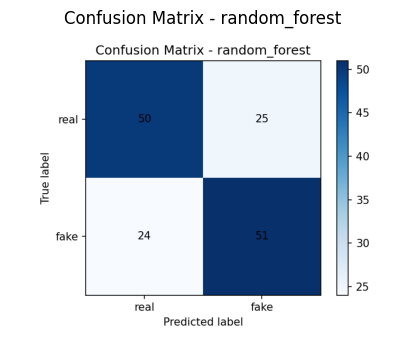

In [8]:
def show_confusion_matrix_image(model_name: str) -> None:
    """Menampilkan file confusion matrix yang disimpan oleh evaluate_model."""
    image_path = FIGURES_DIR / f"confusion_matrix_{model_name}.png"
    if not image_path.exists():
        print(f"Confusion matrix belum tersedia: {image_path}")
        return

    image = plt.imread(image_path)
    plt.figure(figsize=(5, 4))
    plt.imshow(image)
    plt.axis("off")
    plt.title(f"Confusion Matrix - {model_name}")
    plt.show()


if can_train and random_forest_model is not None:
    rf_result = evaluate_model(random_forest_model, X_test, y_test, "random_forest")
    display(pd.DataFrame([rf_result]).drop(columns=["classification_report", "confusion_matrix_path"]))
    show_confusion_matrix_image("random_forest")
else:
    rf_result = None
    print("Evaluasi Random Forest dilewati karena model belum dilatih.")

## Training Support Vector Machine (SVM)

Support Vector Machine mencari boundary terbaik untuk memisahkan class `real` dan `fake`. Pada notebook ini, SVM menggunakan kernel RBF sehingga dapat memodelkan pola pemisahan yang non-linear pada ruang fitur.

Kernel RBF lebih berat secara komputasi dibandingkan Random Forest pada dataset besar karena proses training SVM bergantung pada perbandingan antar sample. Agar demo tetap cepat dan stabil, Random Forest tetap dilatih menggunakan seluruh data training, sedangkan SVM menggunakan stratified sample maksimal 5000 baris dari `X_train` dan `y_train`. Stratified sampling menjaga rasio `real` dan `fake` tetap seimbang.

In [9]:
if can_train:
    svm_training_rows = min(5000, len(X_train))
    print(f"Jumlah row untuk training SVM: {svm_training_rows} dari {len(X_train)} data train")
    svm_model = train_svm(X_train, y_train)
    print("SVM berhasil dilatih.")
else:
    svm_model = None
    print("Training SVM dilewati karena dataset belum valid untuk klasifikasi.")

Jumlah row untuk training SVM: 348 dari 348 data train
SVM training rows: 348
SVM berhasil dilatih.


## Evaluasi SVM

Evaluasi SVM dilakukan dengan metrik yang sama seperti Random Forest agar kedua model dapat dibandingkan secara adil. Confusion matrix juga disimpan sebagai gambar di folder `outputs/figures/`.


svm evaluation
Accuracy: 0.4733
Precision: 0.4796
Recall: 0.6267
F1-score: 0.5434
Classification report:
              precision    recall  f1-score   support

        real       0.46      0.32      0.38        75
        fake       0.48      0.63      0.54        75

    accuracy                           0.47       150
   macro avg       0.47      0.47      0.46       150
weighted avg       0.47      0.47      0.46       150

Saved confusion matrix to: C:\Users\Kei\Documents\computer-vision\Comp_pision\outputs\figures\confusion_matrix_svm.png


,model,accuracy,precision,recall,f1_score
0,svm,0.473333,0.479592,0.626667,0.543353


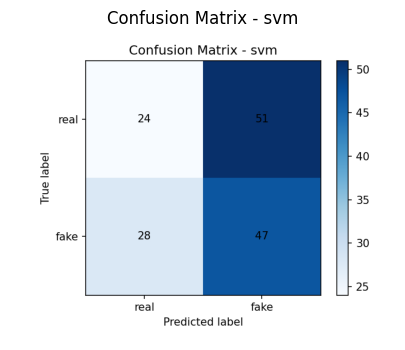

In [10]:
if can_train and svm_model is not None:
    svm_result = evaluate_model(svm_model, X_test, y_test, "svm")
    display(pd.DataFrame([svm_result]).drop(columns=["classification_report", "confusion_matrix_path"]))
    show_confusion_matrix_image("svm")
else:
    svm_result = None
    print("Evaluasi SVM dilewati karena model belum dilatih.")

## Perbandingan Model

Jika kedua model berhasil dilatih, hasil evaluasi dirangkum dalam tabel perbandingan. Bar chart digunakan untuk membandingkan accuracy, precision, recall, dan F1-score antara Random Forest dan SVM.


Saved ML evaluation results to: C:\Users\Kei\Documents\computer-vision\Comp_pision\outputs\results\ml_evaluation_results.csv


,model,accuracy,precision,recall,f1_score
0,random_forest,0.673333,0.671053,0.680000,0.675497
1,svm,0.473333,0.479592,0.626667,0.543353


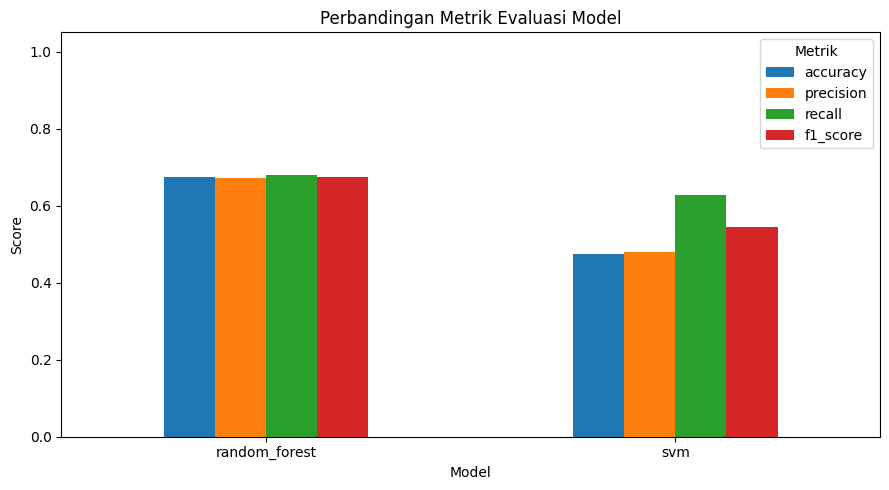

,model,accuracy,precision,recall,f1_score
0,random_forest,0.673333,0.671053,0.680000,0.675497
1,svm,0.473333,0.479592,0.626667,0.543353


In [11]:
model_results = [result for result in [rf_result, svm_result] if result is not None]

if model_results:
    save_results(model_results)
    comparison_df = pd.DataFrame(model_results)[
        ["model", "accuracy", "precision", "recall", "f1_score"]
    ]
    display(comparison_df)

    ax = comparison_df.set_index("model").plot(kind="bar", figsize=(9, 5))
    ax.set_title("Perbandingan Metrik Evaluasi Model")
    ax.set_xlabel("Model")
    ax.set_ylabel("Score")
    ax.set_ylim(0, 1.05)
    ax.tick_params(axis="x", rotation=0)
    ax.legend(title="Metrik")
    plt.tight_layout()
    plt.show()
else:
    comparison_df = pd.DataFrame(
        columns=["model", "accuracy", "precision", "recall", "f1_score"]
    )
    print("Belum ada hasil model untuk dibandingkan karena training/evaluasi dilewati.")

comparison_df

## Analisis Hasil

Jika evaluasi berhasil dijalankan, model dengan F1-score dan accuracy lebih tinggi dapat dianggap lebih baik pada dataset uji yang tersedia. Random Forest biasanya kuat untuk fitur tabular karena menggabungkan banyak decision tree, sedangkan SVM dapat bekerja baik ketika boundary antar kelas dapat dipisahkan dengan kernel yang sesuai.

Augmentasi dapat memengaruhi kualitas feature vector. Misalnya, Gaussian noise dapat mengubah pola lokal descriptor, sedangkan JPEG compression mungkin masih mempertahankan struktur penting pada beberapa citra. Karena fitur ML berasal dari keypoint, descriptor statistics, dan matching robustness, kualitas descriptor akan berpengaruh langsung terhadap kualitas input model.

Keterbatasan penting dari pipeline ini adalah kebutuhan dataset yang seimbang. Jika data hanya berisi `real` atau hanya `fake`, evaluasi klasifikasi tidak valid karena model tidak belajar perbedaan antar kelas. Dataset yang lebih baik perlu memiliki jumlah sample real dan fake yang cukup, serta sebaiknya mencakup variasi augmentasi yang representatif.

## Kesimpulan

Classical Machine Learning dapat menggunakan descriptor statistics dan matching statistics sebagai feature vector untuk klasifikasi real vs fake. Descriptor robustness memengaruhi kualitas fitur karena perubahan pada local feature dapat mengubah jumlah keypoint, statistik descriptor, dan jumlah good matches.

Pipeline ini bersifat modular karena logic utama berada di `src/ml_pipeline.py`. Notebook berfungsi sebagai media demo dan analisis. Untuk evaluasi yang valid, dataset harus memiliki sample `real` dan `fake` yang cukup sehingga model dapat dilatih dan diuji secara adil.